In [1]:
%cd ../..

/scratch/big/home/daawic/BSc-Thesis


In [3]:
import os
import torch
import matplotlib.pyplot as plt
import scienceplots
from torchvision.transforms import transforms
from project.models import EDMSerie
from project.util.device import get_available_acc
from project.util.transforms import Difference
from project.util.data import ReplayMemoryData
from project.util.metrics import PSNR, MSE

In [4]:
plt.style.use(['science','no-latex', 'nature'])

In [5]:
PATH = os.path.join("..", "checkpoints", "diff", "Breakout.pt")
DATA = os.path.join("..", "checkpoints", "memory", "Breakout.pt")

In [6]:
device = "cuda:5"

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2),
    transforms.Normalize(0.5, 0.5),
])

In [8]:
data = ReplayMemoryData(
    memory=DATA,
    transform=transform,
    cap=500_000,
    train=False,
)

In [9]:
SIGMA = 0.5

In [10]:
psnrs = []
psnrs = []

mses = []
mses = []

n = 64
x = torch.zeros((n, 4, 88, 88), device=device)

for i, img in enumerate(torch.randperm(10_000)[:n]):
    x[i] = data[img].to(device)

e = SIGMA * torch.randn_like(x)
x_noisy = x + e

model = EDMSerie.from_checkpoint(PATH, device, sigma_noise=SIGMA, N=32).to(device)

for N in range(2, 15):

    model.set_N(N)

    with torch.no_grad():
        x_denoised = model.denoise(x_noisy)
        psnrs.append(PSNR(x.to("cpu"), x_denoised.to("cpu"), torch.tensor(2)))
        mses.append(MSE(x.to("cpu"), x_denoised.to("cpu")))

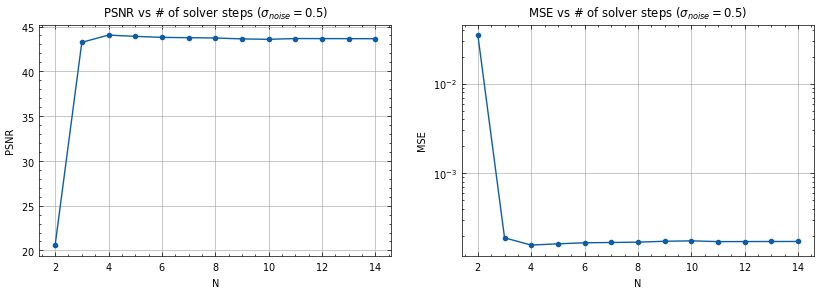

In [16]:
Ns = torch.arange(2, 15)

fig, axis = plt.subplots(1, 2, figsize=(10, 3), sharex=True)

axis[0].plot(Ns, psnrs, "o-")
axis[0].set_xlabel("N")
axis[0].set_ylabel("PSNR")
axis[0].set_title("PSNR vs # of solver steps ($\\sigma_{noise} = " + str(SIGMA) + "$)")
axis[0].grid()

axis[1].semilogy(Ns, mses, "o-")
axis[1].set_xlabel("N")
axis[1].set_ylabel("MSE")
axis[1].set_title("MSE vs # of solver steps ($\\sigma_{noise} = " + str(SIGMA) + "$)")
axis[1].grid()

plt.show()